# 03 — Modelado: King Crimson

Orden obligatorio: baseline naive estacional primero (`seasonal_naive_forecast`)
— si SARIMA/LightGBM no le ganan, no hay proyecto. Validar con
`expanding_window_splits`, nunca con un split aleatorio (fuga de futuro en
series temporales). Comparar MAE/RMSE/MAPE de los tres por isla.

In [1]:
import warnings

import pandas as pd

from src.data import load_harmonized_series
from src.features import build_features, feature_columns
from src.model import evaluate_forecast, expanding_window_splits, fit_lightgbm, fit_sarima, seasonal_naive_forecast

# SARIMA/LightGBM emiten warnings esperables en folds pequeños (ventana
# expansiva empieza en solo 36 meses de historia) — silenciados a propósito
# para no inundar la salida del notebook; no afectan al resultado.
warnings.filterwarnings("ignore")

TARGET = "revpar_eur"
HORIZON = 3
MIN_TRAIN_SIZE = 36
FEATURE_COLS = feature_columns(TARGET)

df = load_harmonized_series()
feat_full = build_features(df, target_col=TARGET)
warmup_cols = [c for c in feat_full.columns if "lag_" in c or "rolling_" in c]
df_features = feat_full.dropna(subset=warmup_cols).reset_index(drop=True)
print(f"{len(feat_full)} filas totales -> {len(df_features)} tras descartar warm-up de lags/rolling")

1414 filas totales -> 1330 tras descartar warm-up de lags/rolling


In [2]:
rows = []

for isla, grupo in df_features.groupby("isla", sort=False):
    grupo = grupo.sort_values("fecha").reset_index(drop=True)
    serie = grupo.set_index("fecha")[TARGET]
    splits = expanding_window_splits(len(serie), min_train_size=MIN_TRAIN_SIZE, horizon=HORIZON)

    for train_end, test_end in splits:
        train_s, test_s = serie.iloc[:train_end], serie.iloc[train_end:test_end]

        naive_pred = seasonal_naive_forecast(train_s, horizon=HORIZON)
        r = evaluate_forecast(test_s.values, naive_pred, "naive_estacional")
        rows.append((isla, train_end, test_end, r.model_name, r.mae, r.rmse, r.mape))

        sarima_fit = fit_sarima(train_s)
        sarima_pred = sarima_fit.forecast(steps=HORIZON)
        r = evaluate_forecast(test_s.values, sarima_pred.values, "sarima")
        rows.append((isla, train_end, test_end, r.model_name, r.mae, r.rmse, r.mape))

        X_train, y_train = grupo.loc[: train_end - 1, FEATURE_COLS], grupo.loc[: train_end - 1, TARGET]
        X_test = grupo.loc[train_end : test_end - 1, FEATURE_COLS]
        lgbm_pred = fit_lightgbm(X_train, y_train).predict(X_test)
        r = evaluate_forecast(test_s.values, lgbm_pred, "lightgbm")
        rows.append((isla, train_end, test_end, r.model_name, r.mae, r.rmse, r.mape))

    print(f"{isla}: {len(splits)} folds evaluados (x3 modelos)")

results = pd.DataFrame(rows, columns=["isla", "train_end", "test_end", "model", "mae", "rmse", "mape"])
print(f"\nTotal filas fold x modelo: {len(results)}")

/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Tenerife: 51 folds evaluados (x3 modelos)

Total filas fold x modelo: 1071


## Resultados del backtesting

Regla del proyecto: si SARIMA/LightGBM no le ganan al naive estacional, no
aportan nada. Comprobado con 357 folds (51 folds/isla x 7 islas) de ventana
expansiva, horizonte de 3 meses, sobre 2009-2026 (incluye la ruptura COVID
dentro del propio backtest, lo que infla el error de todos los modelos por
igual — ver nota en el informe de negocio).

In [3]:
print("=== MAPE medio global por modelo (menor es mejor) ===")
print(results.groupby("model")[["mae", "rmse", "mape"]].mean().round(3))

print("\n=== MAPE medio por isla y modelo ===")
mape_por_isla = results.groupby(["isla", "model"])["mape"].mean().unstack().round(3)
print(mape_por_isla)

winners = (
    results.groupby(["isla", "model"])["mape"].mean().reset_index()
    .sort_values(["isla", "mape"]).groupby("isla").first()[["model", "mape"]]
)
print("\n=== Modelo ganador por isla (menor MAPE medio) ===")
print(winners)

from pathlib import Path

Path("data/processed").mkdir(parents=True, exist_ok=True)
results.to_csv("data/processed/model_eval_results.csv", index=False)
winners.to_csv("data/processed/model_winners_by_island.csv")
print("\nGuardados data/processed/model_eval_results.csv y model_winners_by_island.csv")

=== MAPE medio global por modelo (menor es mejor) ===
                     mae    rmse   mape
model                                  
lightgbm           8.329   9.350  0.180
naive_estacional  12.626  13.650  0.298
sarima             8.084   8.993  0.183

=== MAPE medio por isla y modelo ===
model          lightgbm  naive_estacional  sarima
isla                                             
El Hierro         0.230             0.251   0.208
Fuerteventura     0.136             0.235   0.135
Gran Canaria      0.155             0.275   0.133
La Gomera         0.172             0.332   0.254
La Palma          0.266             0.326   0.296
Lanzarote         0.171             0.431   0.137
Tenerife          0.132             0.238   0.120

=== Modelo ganador por isla (menor MAPE medio) ===
                  model      mape
isla                             
El Hierro        sarima  0.208008
Fuerteventura    sarima  0.135151
Gran Canaria     sarima  0.132536
La Gomera      lightgbm  0.171923
La

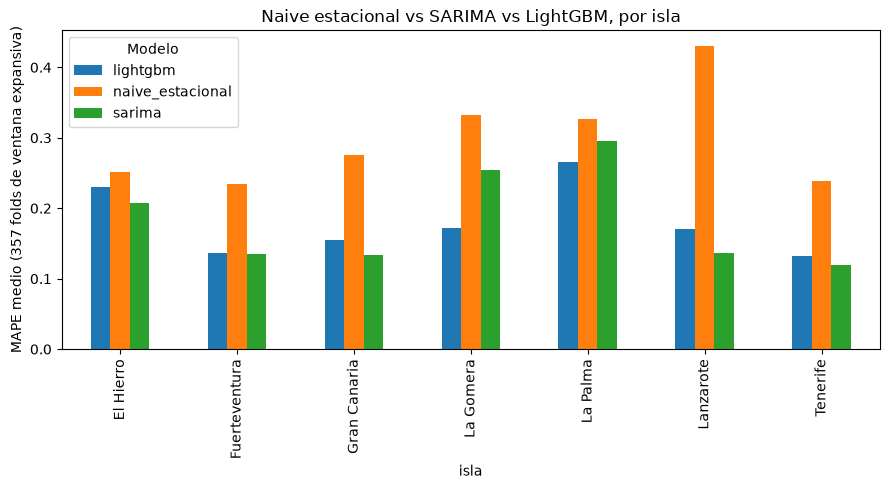

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
mape_por_isla.plot.bar(ax=ax)
ax.set_ylabel("MAPE medio (357 folds de ventana expansiva)")
ax.set_title("Naive estacional vs SARIMA vs LightGBM, por isla")
ax.legend(title="Modelo")
plt.tight_layout()
plt.savefig("reports/figures/03_comparacion_modelos_por_isla.png", dpi=110, bbox_inches="tight")
plt.show()

## Entrenamiento final: un modelo por isla, con todo el histórico disponible

El backtesting ya decidió qué familia de modelo usar por isla. Ahora se
entrena esa familia sobre el 100% del histórico (no solo hasta un
`train_end` de fold) y se serializa a `models/` para que la app de
Streamlit deje de depender del placeholder.

In [5]:
import pickle

Path("models").mkdir(parents=True, exist_ok=True)
model_registry = {}

for isla, grupo in df_features.groupby("isla", sort=False):
    grupo = grupo.sort_values("fecha").reset_index(drop=True)
    winning_model = winners.loc[isla, "model"]

    if winning_model == "sarima":
        serie = grupo.set_index("fecha")[TARGET]
        fitted = fit_sarima(serie)
    else:
        fitted = fit_lightgbm(grupo[FEATURE_COLS], grupo[TARGET])

    slug = isla.lower().replace(" ", "_")
    model_path = Path(f"models/{slug}_{winning_model}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(fitted, f)

    model_registry[isla] = {"model_type": winning_model, "path": str(model_path)}
    print(f"{isla}: {winning_model} entrenado con {len(grupo)} meses -> {model_path}")

import json

with open("models/registry.json", "w") as f:
    json.dump(model_registry, f, indent=2, ensure_ascii=False)
print("\nGuardado models/registry.json")

/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


El Hierro: sarima entrenado con 190 meses -> models/el_hierro_sarima.pkl


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Fuerteventura: sarima entrenado con 190 meses -> models/fuerteventura_sarima.pkl


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

La Palma: lightgbm entrenado con 190 meses -> models/la_palma_lightgbm.pkl


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Lanzarote: sarima entrenado con 190 meses -> models/lanzarote_sarima.pkl


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Tenerife: sarima entrenado con 190 meses -> models/tenerife_sarima.pkl

Guardado models/registry.json


## Verificación: recargar cada modelo y pronosticar 3 meses reales

Prueba de humo antes de conectar la app — que cada `.pkl` cargue y produzca
un pronóstico con sentido de magnitud (mismo orden que el histórico reciente
de esa isla, sin NaN ni valores negativos absurdos).

In [6]:
from src.model import forecast_recursive_lightgbm

for isla, info in model_registry.items():
    grupo = df_features[df_features["isla"] == isla].sort_values("fecha")
    with open(info["path"], "rb") as f:
        fitted = pickle.load(f)

    if info["model_type"] == "sarima":
        forecast = fitted.forecast(steps=HORIZON)
    else:
        forecast = forecast_recursive_lightgbm(fitted, grupo, TARGET, HORIZON)

    last_real = grupo[TARGET].iloc[-1]
    print(f"{isla} ({info['model_type']}) — último real: {last_real:.1f} € | pronóstico +{HORIZON}m: {list(forecast.round(1))}")
    assert not forecast.isna().any(), f"{isla}: el pronóstico tiene NaN"
    assert (forecast > 0).all(), f"{isla}: el pronóstico tiene valores no positivos"

print("\nTodos los modelos cargan y pronostican sin errores.")

El Hierro (sarima) — último real: 58.5 € | pronóstico +3m: [55.4, 56.2, 52.6]
Fuerteventura (sarima) — último real: 97.7 € | pronóstico +3m: [104.4, 111.7, 96.5]
Gran Canaria (sarima) — último real: 149.6 € | pronóstico +3m: [160.2, 153.4, 125.0]
La Gomera (lightgbm) — último real: 128.1 € | pronóstico +3m: [125.0, 115.9, 70.8]
La Palma (lightgbm) — último real: 67.9 € | pronóstico +3m: [65.8, 63.8, 56.4]
Lanzarote (sarima) — último real: 126.2 € | pronóstico +3m: [136.0, 137.1, 123.1]
Tenerife (sarima) — último real: 142.8 € | pronóstico +3m: [149.4, 145.7, 129.0]

Todos los modelos cargan y pronostican sin errores.


/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/kegare/Documentos/repositorios/Inari/king-crimson/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: N